In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import json
import wandb
import tensorflow as tf
from google.colab import userdata

BASE = '/content/drive/MyDrive/Ketastasia/data'

data = np.load(f'{BASE}/dataset_seq_33kp_ready.npz')
X_train, y_train, y_train_idx = data['X_train'], data['y_train'], data['y_train_int']
X_val,   y_val,   y_val_idx   = data['X_val'],   data['y_val'],   data['y_val_int']

with open(f'{BASE}/pipeline2A_metadata.json') as f:
    meta = json.load(f)

n_classes  = len(meta['classes'])
seq_len    = meta['sequence_length']
n_features = meta['n_features_per_frame']

print(f"Loaded: X_train {X_train.shape}, y_train (one-hot) {y_train.shape}, y_train_idx (int) {y_train_idx.shape}")

wandb_api_key = userdata.get('WANDB_API_KEY_1')
wandb.login(key=wandb_api_key)

Mounted at /content/drive
Loaded: X_train (5579, 15, 72), y_train (one-hot) (5579, 26), y_train_idx (int) (5579,)


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: akeke23 (akeke23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

os.makedirs(f'{BASE}/models', exist_ok=True)

classes = meta['classes']

In [3]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, GlobalAveragePooling1D, Dense
from tensorflow.keras.optimizers import Adam

def build_cnn_baseline(filters=64, n_conv_layers=3, lr=0.001):
    inp = Input(shape=(seq_len, n_features))
    x = inp

    for i in range(n_conv_layers):
        dilation = 2 ** i  # 1, 2, 4, 8...
        x = Conv1D(filters, kernel_size=3, dilation_rate=dilation,
                   padding='causal', activation='relu')(x)

    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    out = Dense(n_classes, activation='softmax')(x)

    model = Model(inp, out)
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [4]:
configs = [
    {'name': 'small',  'filters': 32, 'n_conv_layers': 2, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'name': 'medium', 'filters': 64, 'n_conv_layers': 3, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'name': 'large',  'filters': 128, 'n_conv_layers': 4, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
]
print(f"Prepared {len(configs)} capacity variants (small/medium/large)")

Prepared 3 capacity variants (small/medium/large)


In [5]:
from wandb.integration.keras import WandbMetricsLogger
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

best_val_acc = 0
best_run_name = None
baseline_results = []

for cfg in configs:
    run_name = f"cnn_baseline_{cfg['name']}"
    architecture_name = f"CNN-baseline-{cfg['name']}"

    print(f"\n{'-'*60}\nStarting Baseline experiment: {run_name}\n{'-'*60}")

    wandb.init(
        project='ildolcefarniente',
        group='p2_cnn',
        name=run_name,
        config={
            **cfg,
            'model': 'cnn',
            'architecture': architecture_name,
            'dropout_included': False,
            'class_weights_included': False,
            'seq_len': seq_len,
            'n_features': n_features,
            'n_classes': n_classes,
            'pipeline': 'pipeline2A_33kp',
            'normalization': 'hip_centered_shoulder_hip_scaled'
        },
        reinit=True
    )

    model = build_cnn_baseline(
        filters=cfg['filters'],
        n_conv_layers=cfg['n_conv_layers'],
        lr=cfg['lr']
    )

    callbacks = [
        WandbMetricsLogger(log_freq='epoch'),
        EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=cfg['epochs'],
        batch_size=cfg['batch_size'],
        callbacks=callbacks,
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    best_epoch_idx = np.argmax(history.history['val_accuracy'])
    train_acc_at_best = history.history['accuracy'][best_epoch_idx]
    gap = train_acc_at_best - val_acc

    y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)

    report_val = classification_report(
        y_val_idx, y_pred_val,
        labels=list(range(len(classes))),
        target_names=classes,
        output_dict=True
    )

    cm_val = confusion_matrix(y_val_idx, y_pred_val)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f'Val Confusion Matrix (Baseline) - {run_name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Val Label')
    ax.set_xlabel('Predicted Val Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    cm_path = f'/content/{run_name}_val_cm.png'
    plt.savefig(cm_path, dpi=150)
    plt.close()

    wandb.log({
        'final_val_accuracy': val_acc,
        'final_val_loss': val_loss,
        'train_acc_at_best': train_acc_at_best,
        'overfitting_gap': gap,
        'val_f1_macro': report_val['macro avg']['f1-score'],
        'val_f1_weighted': report_val['weighted avg']['f1-score'],
        'val_confusion_matrix_db': wandb.plot.confusion_matrix(
            probs=None, y_true=y_val_idx.tolist(), preds=y_pred_val.tolist(), class_names=classes
        ),
        'val_confusion_matrix_img': wandb.Image(cm_path)
    })

    model_path = f'{BASE}/models/{run_name}.keras'
    model.save(model_path)

    baseline_results.append({
        'run_name': run_name, 'filters': cfg['filters'], 'n_conv_layers': cfg['n_conv_layers'],
        'train_acc': train_acc_at_best, 'val_acc': val_acc, 'gap': gap,
        'val_loss': val_loss, 'val_f1_macro': report_val['macro avg']['f1-score']
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_run_name = run_name

    print(f"Run {run_name} completed. Val Accuracy: {val_acc:.4f}, Gap: {gap:.4f}")
    wandb.finish()

baseline_df = pd.DataFrame(baseline_results).sort_values('val_acc', ascending=False)
print(f"\n{'='*60}\nBaseline experiments completed!\n{'='*60}")
print(baseline_df[['run_name', 'filters', 'n_conv_layers', 'train_acc', 'val_acc', 'gap', 'val_loss', 'val_f1_macro']])
print(f"\nBest: {best_run_name} (Val Acc: {best_val_acc:.4f})")


------------------------------------------------------------
Starting Baseline experiment: cnn_baseline_small
------------------------------------------------------------


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.4046 - loss: 2.0174 - val_accuracy: 0.4828 - val_loss: 1.8506 - learning_rate: 0.0010
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6567 - loss: 1.0651 - val_accuracy: 0.5363 - val_loss: 1.8638 - learning_rate: 0.0010
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7369 - loss: 0.8102 - val_accuracy: 0.5926 - val_loss: 1.8351 - learning_rate: 0.0010
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7847 - loss: 0.6798 - val_accuracy: 0.5499 - val_loss: 1.9258 - learning_rate: 0.0010
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8209 - loss: 0.5767 - val_accuracy: 0.5944 - val_loss: 1.8698 - learning_rate: 0.0010
Epoch 6/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8290 - loss: 0.5309 - val_accuracy: 0.5980 - val_loss: 1.9604 - learning_rate: 0.0010
Epoch 7/40
173/175 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8525 - loss: 0.4660

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run cnn_baseline_small completed. Val Accuracy: 0.6252, Gap: 0.2938


...

Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.4802 - loss: 1.7230 - val_accuracy: 0.5454 - val_loss: 1.6998 - learning_rate: 0.0010
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.6955 - loss: 0.9320 - val_accuracy: 0.5154 - val_loss: 1.7623 - learning_rate: 0.0010
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7802 - loss: 0.6675 - val_accuracy: 0.5535 - val_loss: 1.6958 - learning_rate: 0.0010
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8304 - loss: 0.5228 - val_accuracy: 0.6171 - val_loss: 1.7455 - learning_rate: 0.0010
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.8666 - loss: 0.4138 - val_accuracy: 0.5917 - val_loss: 1.8612 - learning_rate: 0.0010
Epoch 6/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8713 - loss: 0.3944 - val_accuracy: 0.6343 - val_loss: 1.9131 - learning_rate: 0.0010
Epoch 7/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8871 - loss: 0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run cnn_baseline_large completed. Val Accuracy: 0.6733, Gap: 0.3148


epoch/accuracy,▁▄▅▆▆▆▇▇▇▇██████████████
epoch/epoch,▁▁▂▂▂▃▃▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇██
epoch/learning_rate,███████▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁
epoch/loss,█▅▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▂▁▃▆▄▆▆▇▆█▇██▇██▇███████
epoch/val_loss,▁▁▁▁▂▂▁▃▃▃▅▄▅▆▅▆▆▇█▇▇███
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...



Baseline experiments completed!
              run_name  filters  n_conv_layers  train_acc   val_acc       gap  \
1  cnn_baseline_medium       64              3   0.976878  0.675136  0.301741   
2   cnn_baseline_large      128              4   0.988170  0.673321  0.314849   
0   cnn_baseline_small       32              2   0.918982  0.625227  0.293755   

   val_loss  val_f1_macro  
1  2.533129      0.558845  
2  2.537428      0.559261  
0  2.077528      0.507555  

Best: cnn_baseline_medium (Val Acc: 0.6751)


In [6]:
from tensorflow.keras.layers import SpatialDropout1D

def build_cnn_dropout(filters, n_conv_layers, dropout_rate, lr=0.001):
    inp = Input(shape=(seq_len, n_features))
    x = inp

    for i in range(n_conv_layers):
        dilation = 2 ** i
        x = Conv1D(filters, kernel_size=3, dilation_rate=dilation,
                   padding='causal', activation='relu')(x)
        x = SpatialDropout1D(dropout_rate)(x)

    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    out = Dense(n_classes, activation='softmax')(x)

    model = Model(inp, out)
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [7]:
configs_dropout = [
    {'name': 'dropout_0.2', 'filters': 64, 'n_conv_layers': 3, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'name': 'dropout_0.3', 'filters': 64, 'n_conv_layers': 3, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'name': 'dropout_0.4', 'filters': 64, 'n_conv_layers': 3, 'dropout': 0.4, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'name': 'dropout_0.5', 'filters': 64, 'n_conv_layers': 3, 'dropout': 0.5, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'name': 'dropout_0.8', 'filters': 64, 'n_conv_layers': 3, 'dropout': 0.8, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
]
print(f"Prepared {len(configs_dropout)} dropout values (capacity fixed: medium)")

Prepared 5 dropout values (capacity fixed: medium)


In [8]:
best_val_acc_dropout = 0
best_run_name_dropout = None
dropout_results = []

for cfg in configs_dropout:
    run_name = f"cnn_{cfg['name']}"
    architecture_name = f"CNN-{cfg['name']}"

    print(f"\n{'-'*60}\nStarting Dropout experiment: {run_name}\n{'-'*60}")

    wandb.init(
        project='ildolcefarniente',
        group='p2_cnn',
        name=run_name,
        config={
            **cfg,
            'model': 'cnn',
            'architecture': architecture_name,
            'dropout_included': True,
            'class_weights_included': False,
            'seq_len': seq_len,
            'n_features': n_features,
            'n_classes': n_classes,
            'pipeline': 'pipeline2A_33kp',
            'normalization': 'hip_centered_shoulder_hip_scaled'
        },
        reinit=True
    )

    model = build_cnn_dropout(
        filters=cfg['filters'],
        n_conv_layers=cfg['n_conv_layers'],
        dropout_rate=cfg['dropout'],
        lr=cfg['lr']
    )

    callbacks = [
        WandbMetricsLogger(log_freq='epoch'),
        EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=cfg['epochs'],
        batch_size=cfg['batch_size'],
        callbacks=callbacks,
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    best_epoch_idx = np.argmax(history.history['val_accuracy'])
    train_acc_at_best = history.history['accuracy'][best_epoch_idx]
    gap = train_acc_at_best - val_acc

    y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)

    report_val = classification_report(
        y_val_idx, y_pred_val,
        labels=list(range(len(classes))),
        target_names=classes,
        output_dict=True
    )

    cm_val = confusion_matrix(y_val_idx, y_pred_val)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f'Val Confusion Matrix (Dropout) - {run_name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Val Label')
    ax.set_xlabel('Predicted Val Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    cm_path = f'/content/{run_name}_val_cm.png'
    plt.savefig(cm_path, dpi=150)
    plt.close()

    wandb.log({
        'final_val_accuracy': val_acc,
        'final_val_loss': val_loss,
        'train_acc_at_best': train_acc_at_best,
        'overfitting_gap': gap,
        'val_f1_macro': report_val['macro avg']['f1-score'],
        'val_f1_weighted': report_val['weighted avg']['f1-score'],
        'val_confusion_matrix_db': wandb.plot.confusion_matrix(
            probs=None, y_true=y_val_idx.tolist(), preds=y_pred_val.tolist(), class_names=classes
        ),
        'val_confusion_matrix_img': wandb.Image(cm_path)
    })

    model_path = f'{BASE}/models/{run_name}.keras'
    model.save(model_path)

    dropout_results.append({
        'run_name': run_name, 'dropout': cfg['dropout'],
        'train_acc': train_acc_at_best, 'val_acc': val_acc, 'gap': gap,
        'val_loss': val_loss, 'val_f1_macro': report_val['macro avg']['f1-score']
    })

    if val_acc > best_val_acc_dropout:
        best_val_acc_dropout = val_acc
        best_run_name_dropout = run_name

    print(f"Run {run_name} completed. Val Accuracy: {val_acc:.4f}, Gap: {gap:.4f}")
    wandb.finish()

dropout_df = pd.DataFrame(dropout_results).sort_values('val_acc', ascending=False)
print(f"\n{'='*60}\nDropout sweep completed!\n{'='*60}")
print(dropout_df[['run_name', 'dropout', 'train_acc', 'val_acc', 'gap', 'val_loss', 'val_f1_macro']])
print(f"\nBest: {best_run_name_dropout} (Val Acc: {best_val_acc_dropout:.4f})")


------------------------------------------------------------
Starting Dropout experiment: cnn_dropout_0.2
------------------------------------------------------------


Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.3361 - loss: 2.2425 - val_accuracy: 0.4083 - val_loss: 1.8904 - learning_rate: 0.0010
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4983 - loss: 1.5391 - val_accuracy: 0.5091 - val_loss: 1.6629 - learning_rate: 0.0010
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5743 - loss: 1.2894 - val_accuracy: 0.5000 - val_loss: 1.6421 - learning_rate: 0.0010
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6256 - loss: 1.1478 - val_accuracy: 0.4909 - val_loss: 1.6023 - learning_rate: 0.0010
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6542 - loss: 1.0433 - val_accuracy: 0.5635 - val_loss: 1.4564 - learning_rate: 0.0010
Epoch 6/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6749 - loss: 0.9700 - val_accuracy: 0.5544 - val_loss: 1.6186 - learning_rate: 0.0010
Epoch 7/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6917 - loss: 0.928

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run cnn_dropout_0.2 completed. Val Accuracy: 0.6906, Gap: 0.1496


epoch/accuracy,▁▃▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇█████████████████
epoch/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
epoch/learning_rate,██████████████████▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁
epoch/loss,█▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▃▃▅▅▆▅▆▆▆▆▆▇▇▇▇▇█▇▇█▇▇▇██████████
epoch/val_loss,█▅▅▄▂▅▃▁▂▃▁▂▂▁▁▃▁▂▂▂▃▁▁▂▂▂▁▂▂▁▁▂▂▂▂
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...


...

Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.0928 - loss: 3.2401 - val_accuracy: 0.1325 - val_loss: 3.1607 - learning_rate: 0.0010
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1351 - loss: 2.9568 - val_accuracy: 0.1243 - val_loss: 3.0740 - learning_rate: 0.0010
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.1645 - loss: 2.8495 - val_accuracy: 0.1270 - val_loss: 3.0052 - learning_rate: 0.0010
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1733 - loss: 2.7880 - val_accuracy: 0.1379 - val_loss: 2.9173 - learning_rate: 0.0010
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.1918 - loss: 2.7056 - val_accuracy: 0.1770 - val_loss: 2.8597 - learning_rate: 0.0010
Epoch 6/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2058 - loss: 2.6453 - val_accuracy: 0.1652 - val_loss: 2.8656 - learning_rate: 0.0010
Epoch 7/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2190 - loss: 2.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run cnn_dropout_0.8 completed. Val Accuracy: 0.2223, Gap: 0.0017


epoch/accuracy,▁▃▄▄▅▆▆▆▇▇▇▇▇▇██
epoch/epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇██
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▅▄▃▃▃▂▂▂▂▂▁▁▁
epoch/val_accuracy,▂▁▁▂▅▄▅█▅▅▅▅▅▄▄▄
epoch/val_loss,█▇▆▅▄▄▃▃▂▃▂▃▂▁▂▁
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...



Dropout sweep completed!
          run_name  dropout  train_acc   val_acc       gap  val_loss  \
0  cnn_dropout_0.2      0.2   0.840115  0.690563  0.149552  1.364039   
1  cnn_dropout_0.3      0.3   0.799247  0.683303  0.115944  1.216491   
2  cnn_dropout_0.4      0.4   0.715720  0.633394  0.082326  1.330137   
3  cnn_dropout_0.5      0.5   0.606023  0.537205  0.068817  1.479996   
4  cnn_dropout_0.8      0.8   0.224054  0.222323  0.001731  2.780317   

   val_f1_macro  
0      0.581215  
1      0.577637  
2      0.514927  
3      0.393654  
4      0.063837  

Best: cnn_dropout_0.2 (Val Acc: 0.6906)


batchnorm

In [9]:
from tensorflow.keras.layers import BatchNormalization

def build_cnn_batchnorm(filters, n_conv_layers, dropout_rate, lr=0.001):
    inp = Input(shape=(seq_len, n_features))
    x = inp

    for i in range(n_conv_layers):
        dilation = 2 ** i
        x = Conv1D(filters, kernel_size=3, dilation_rate=dilation, padding='causal')(x)
        x = BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)
        x = SpatialDropout1D(dropout_rate)(x)

    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    out = Dense(n_classes, activation='softmax')(x)

    model = Model(inp, out)
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [10]:
config_batchnorm = {
    'name': 'dropout_0.3_batchnorm',
    'filters': 64, 'n_conv_layers': 3, 'dropout': 0.3, 'lr': 0.001,
    'batch_size': 32, 'epochs': 40
}

run_name = f"cnn_{config_batchnorm['name']}"
architecture_name = f"CNN-{config_batchnorm['name']}"

print(f"\n{'-'*60}\nStarting BatchNorm experiment: {run_name}\n{'-'*60}")

wandb.init(
    project='ildolcefarniente',
    group='p2_cnn',
    name=run_name,
    config={
        **config_batchnorm,
        'model': 'cnn',
        'architecture': architecture_name,
        'dropout_included': True,
        'batchnorm_included': True,
        'class_weights_included': False,
        'seq_len': seq_len,
        'n_features': n_features,
        'n_classes': n_classes,
        'pipeline': 'pipeline2A_33kp',
        'normalization': 'hip_centered_shoulder_hip_scaled'
    },
    reinit=True
)

model = build_cnn_batchnorm(
    filters=config_batchnorm['filters'],
    n_conv_layers=config_batchnorm['n_conv_layers'],
    dropout_rate=config_batchnorm['dropout'],
    lr=config_batchnorm['lr']
)

callbacks = [
    WandbMetricsLogger(log_freq='epoch'),
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=config_batchnorm['epochs'],
    batch_size=config_batchnorm['batch_size'],
    callbacks=callbacks,
    verbose=1
)

val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

best_epoch_idx = np.argmax(history.history['val_accuracy'])
train_acc_at_best = history.history['accuracy'][best_epoch_idx]
gap = train_acc_at_best - val_acc

y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)

report_val = classification_report(
    y_val_idx, y_pred_val,
    labels=list(range(len(classes))),
    target_names=classes,
    output_dict=True
)

cm_val = confusion_matrix(y_val_idx, y_pred_val)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_title(f'Val Confusion Matrix (BatchNorm) - {run_name}', fontsize=12, fontweight='bold')
ax.set_ylabel('True Val Label')
ax.set_xlabel('Predicted Val Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
cm_path = f'/content/{run_name}_val_cm.png'
plt.savefig(cm_path, dpi=150)
plt.close()

wandb.log({
    'final_val_accuracy': val_acc,
    'final_val_loss': val_loss,
    'train_acc_at_best': train_acc_at_best,
    'overfitting_gap': gap,
    'val_f1_macro': report_val['macro avg']['f1-score'],
    'val_f1_weighted': report_val['weighted avg']['f1-score'],
    'val_confusion_matrix_db': wandb.plot.confusion_matrix(
        probs=None, y_true=y_val_idx.tolist(), preds=y_pred_val.tolist(), class_names=classes
    ),
    'val_confusion_matrix_img': wandb.Image(cm_path)
})

model_path = f'{BASE}/models/{run_name}.keras'
model.save(model_path)

print(f"Run {run_name} completed. Val Accuracy: {val_acc:.4f}, Gap: {gap:.4f}, F1_macro: {report_val['macro avg']['f1-score']:.4f}")
wandb.finish()


------------------------------------------------------------
Starting BatchNorm experiment: cnn_dropout_0.3_batchnorm
------------------------------------------------------------


Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.2975 - loss: 2.4202 - val_accuracy: 0.4047 - val_loss: 1.9728 - learning_rate: 0.0010
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4366 - loss: 1.8095 - val_accuracy: 0.4492 - val_loss: 1.7219 - learning_rate: 0.0010
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4750 - loss: 1.5994 - val_accuracy: 0.5064 - val_loss: 1.6006 - learning_rate: 0.0010
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5094 - loss: 1.4815 - val_accuracy: 0.5263 - val_loss: 1.4620 - learning_rate: 0.0010
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5456 - loss: 1.3790 - val_accuracy: 0.5372 - val_loss: 1.4937 - learning_rate: 0.0010
Epoch 6/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5625 - loss: 1.3269 - val_accuracy: 0.5417 - val_loss: 1.4192 - learning_rate: 0.0010
Epoch 7/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5775 - loss: 1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run cnn_dropout_0.3_batchnorm completed. Val Accuracy: 0.6615, Gap: 0.0712, F1_macro: 0.5363


epoch/accuracy,▁▃▄▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█▇██████████████
epoch/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
epoch/learning_rate,████████████████████▄▄▄▄▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁
epoch/loss,█▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▂▄▄▅▅▆▅▅▆▇▆▆▇▆▆▇▇▇▇██▇▇▇▇███▇██████████
epoch/val_loss,█▆▅▃▄▃▃▃▃▃▃▃▃▂▂▁▂▂▃▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...


In [12]:
config_batchnorm = {
    'name': 'dropout_0.2_batchnorm',
    'filters': 64, 'n_conv_layers': 3, 'dropout': 0.2, 'lr': 0.001,
    'batch_size': 32, 'epochs': 40
}

run_name = f"cnn_{config_batchnorm['name']}"
architecture_name = f"CNN-{config_batchnorm['name']}"

print(f"\n{'-'*60}\nStarting BatchNorm experiment: {run_name}\n{'-'*60}")

wandb.init(
    project='ildolcefarniente',
    group='p2_cnn',
    name=run_name,
    config={
        **config_batchnorm,
        'model': 'cnn',
        'architecture': architecture_name,
        'dropout_included': True,
        'batchnorm_included': True,
        'class_weights_included': False,
        'seq_len': seq_len,
        'n_features': n_features,
        'n_classes': n_classes,
        'pipeline': 'pipeline2A_33kp',
        'normalization': 'hip_centered_shoulder_hip_scaled'
    },
    reinit=True
)

model = build_cnn_batchnorm(
    filters=config_batchnorm['filters'],
    n_conv_layers=config_batchnorm['n_conv_layers'],
    dropout_rate=config_batchnorm['dropout'],
    lr=config_batchnorm['lr']
)

callbacks = [
    WandbMetricsLogger(log_freq='epoch'),
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=config_batchnorm['epochs'],
    batch_size=config_batchnorm['batch_size'],
    callbacks=callbacks,
    verbose=1
)

val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

best_epoch_idx = np.argmax(history.history['val_accuracy'])
train_acc_at_best = history.history['accuracy'][best_epoch_idx]
gap = train_acc_at_best - val_acc

y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)

report_val = classification_report(
    y_val_idx, y_pred_val,
    labels=list(range(len(classes))),
    target_names=classes,
    output_dict=True
)

cm_val = confusion_matrix(y_val_idx, y_pred_val)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_title(f'Val Confusion Matrix (BatchNorm) - {run_name}', fontsize=12, fontweight='bold')
ax.set_ylabel('True Val Label')
ax.set_xlabel('Predicted Val Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
cm_path = f'/content/{run_name}_val_cm.png'
plt.savefig(cm_path, dpi=150)
plt.close()

wandb.log({
    'final_val_accuracy': val_acc,
    'final_val_loss': val_loss,
    'train_acc_at_best': train_acc_at_best,
    'overfitting_gap': gap,
    'val_f1_macro': report_val['macro avg']['f1-score'],
    'val_f1_weighted': report_val['weighted avg']['f1-score'],
    'val_confusion_matrix_db': wandb.plot.confusion_matrix(
        probs=None, y_true=y_val_idx.tolist(), preds=y_pred_val.tolist(), class_names=classes
    ),
    'val_confusion_matrix_img': wandb.Image(cm_path)
})

model_path = f'{BASE}/models/{run_name}.keras'
model.save(model_path)

print(f"Run {run_name} completed. Val Accuracy: {val_acc:.4f}, Gap: {gap:.4f}, F1_macro: {report_val['macro avg']['f1-score']:.4f}")
wandb.finish()


------------------------------------------------------------
Starting BatchNorm experiment: cnn_dropout_0.2_batchnorm
------------------------------------------------------------


Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.3547 - loss: 2.2328 - val_accuracy: 0.4102 - val_loss: 1.8819 - learning_rate: 0.0010
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5069 - loss: 1.5417 - val_accuracy: 0.5172 - val_loss: 1.5622 - learning_rate: 0.0010
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5637 - loss: 1.3229 - val_accuracy: 0.5590 - val_loss: 1.4643 - learning_rate: 0.0010
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5981 - loss: 1.2054 - val_accuracy: 0.5472 - val_loss: 1.3986 - learning_rate: 0.0010
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6205 - loss: 1.1440 - val_accuracy: 0.5635 - val_loss: 1.4008 - learning_rate: 0.0010
Epoch 6/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6333 - loss: 1.1044 - val_accuracy: 0.5771 - val_loss: 1.3757 - learning_rate: 0.0010
Epoch 7/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6533 - loss: 1.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run cnn_dropout_0.2_batchnorm completed. Val Accuracy: 0.6806, Gap: 0.1163, F1_macro: 0.5679


epoch/accuracy,▁▃▄▅▅▅▆▆▆▆▇▆▇▇▇▇▇▇▇█████████████████████
epoch/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
epoch/learning_rate,███████████████▄▄▄▄▃▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▄▅▅▅▅▆▅▆▇▇▆▇▇▇▇▇▇██████████████████████
epoch/val_loss,█▅▄▃▃▃▂▃▂▂▁▂▃▂▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...


In [11]:
configs_lr = [
    {'name': 'lr_0.01_d0.2',    'filters': 64, 'n_conv_layers': 3, 'dropout': 0.2, 'lr': 0.01,   'batch_size': 32, 'epochs': 40},
    {'name': 'lr_0.001_d0.2',   'filters': 64, 'n_conv_layers': 3, 'dropout': 0.2, 'lr': 0.001,  'batch_size': 32, 'epochs': 40},
    {'name': 'lr_0.0005_d0.2',  'filters': 64, 'n_conv_layers': 3, 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 32, 'epochs': 40},
    {'name': 'lr_0.0001_d0.2',  'filters': 64, 'n_conv_layers': 3, 'dropout': 0.2, 'lr': 0.0001, 'batch_size': 32, 'epochs': 40},
    {'name': 'lr_0.01_d0.3',    'filters': 64, 'n_conv_layers': 3, 'dropout': 0.3, 'lr': 0.01,   'batch_size': 32, 'epochs': 40},
    {'name': 'lr_0.001_d0.3',   'filters': 64, 'n_conv_layers': 3, 'dropout': 0.3, 'lr': 0.001,  'batch_size': 32, 'epochs': 40},
    {'name': 'lr_0.0005_d0.3',  'filters': 64, 'n_conv_layers': 3, 'dropout': 0.3, 'lr': 0.0005, 'batch_size': 32, 'epochs': 40},
    {'name': 'lr_0.0001_d0.3',  'filters': 64, 'n_conv_layers': 3, 'dropout': 0.3, 'lr': 0.0001, 'batch_size': 32, 'epochs': 40},
]
print(f"Prepared {len(configs_lr)} learning rate configs (dropout 0.2 and 0.3 both tested)")

Prepared 8 learning rate configs (dropout 0.2 and 0.3 both tested)


In [13]:
best_val_acc_lr = 0
best_run_name_lr = None
lr_results = []

for cfg in configs_lr:
    run_name = f"cnn_{cfg['name']}"
    architecture_name = f"CNN-{cfg['name']}"

    print(f"\n{'-'*60}\nStarting LR experiment: {run_name}\n{'-'*60}")

    wandb.init(
        project='ildolcefarniente',
        group='p2_cnn',
        name=run_name,
        config={
            **cfg,
            'model': 'cnn',
            'architecture': architecture_name,
            'dropout_included': True,
            'class_weights_included': False,
            'seq_len': seq_len,
            'n_features': n_features,
            'n_classes': n_classes,
            'pipeline': 'pipeline2A_33kp',
            'normalization': 'hip_centered_shoulder_hip_scaled'
        },
        reinit=True
    )

    model = build_cnn_dropout(
        filters=cfg['filters'],
        n_conv_layers=cfg['n_conv_layers'],
        dropout_rate=cfg['dropout'],
        lr=cfg['lr']
    )

    callbacks = [
        WandbMetricsLogger(log_freq='epoch'),
        EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=cfg['epochs'],
        batch_size=cfg['batch_size'],
        callbacks=callbacks,
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    best_epoch_idx = np.argmax(history.history['val_accuracy'])
    train_acc_at_best = history.history['accuracy'][best_epoch_idx]
    gap = train_acc_at_best - val_acc

    y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)

    report_val = classification_report(
        y_val_idx, y_pred_val,
        labels=list(range(len(classes))),
        target_names=classes,
        output_dict=True
    )

    cm_val = confusion_matrix(y_val_idx, y_pred_val)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f'Val Confusion Matrix (LR sweep) - {run_name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Val Label')
    ax.set_xlabel('Predicted Val Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    cm_path = f'/content/{run_name}_val_cm.png'
    plt.savefig(cm_path, dpi=150)
    plt.close()

    wandb.log({
        'final_val_accuracy': val_acc,
        'final_val_loss': val_loss,
        'train_acc_at_best': train_acc_at_best,
        'overfitting_gap': gap,
        'val_f1_macro': report_val['macro avg']['f1-score'],
        'val_f1_weighted': report_val['weighted avg']['f1-score'],
        'val_confusion_matrix_db': wandb.plot.confusion_matrix(
            probs=None, y_true=y_val_idx.tolist(), preds=y_pred_val.tolist(), class_names=classes
        ),
        'val_confusion_matrix_img': wandb.Image(cm_path)
    })

    model_path = f'{BASE}/models/{run_name}.keras'
    model.save(model_path)

    lr_results.append({
        'run_name': run_name, 'lr': cfg['lr'],
        'train_acc': train_acc_at_best, 'val_acc': val_acc, 'gap': gap,
        'val_loss': val_loss, 'val_f1_macro': report_val['macro avg']['f1-score']
    })

    if val_acc > best_val_acc_lr:
        best_val_acc_lr = val_acc
        best_run_name_lr = run_name

    print(f"Run {run_name} completed. Val Accuracy: {val_acc:.4f}, Gap: {gap:.4f}")
    wandb.finish()

lr_df = pd.DataFrame(lr_results).sort_values('val_acc', ascending=False)
print(f"\n{'='*60}\nLearning Rate sweep completed!\n{'='*60}")
print(lr_df[['run_name', 'lr', 'train_acc', 'val_acc', 'gap', 'val_loss', 'val_f1_macro']])
print(f"\nBest: {best_run_name_lr} (Val Acc: {best_val_acc_lr:.4f})")


------------------------------------------------------------
Starting LR experiment: cnn_lr_0.01_d0.2
------------------------------------------------------------


Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.3128 - loss: 2.2233 - val_accuracy: 0.3503 - val_loss: 2.0663 - learning_rate: 0.0100
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4244 - loss: 1.8164 - val_accuracy: 0.3757 - val_loss: 2.2238 - learning_rate: 0.0100
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4526 - loss: 1.6876 - val_accuracy: 0.4891 - val_loss: 1.6525 - learning_rate: 0.0100
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5245 - loss: 1.4784 - val_accuracy: 0.5000 - val_loss: 1.6867 - learning_rate: 0.0100
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5241 - loss: 1.4285 - val_accuracy: 0.5000 - val_loss: 1.6728 - learning_rate: 0.0100
Epoch 6/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5549 - loss: 1.3703 - val_accuracy: 0.5181 - val_loss: 1.6285 - learning_rate: 0.0100
Epoch 7/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5883 - loss: 1.2

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run cnn_lr_0.01_d0.2 completed. Val Accuracy: 0.6543, Gap: 0.1401


epoch/accuracy,▁▃▃▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇████████████
epoch/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
epoch/learning_rate,████████████▄▄▄▄▄▄▄▄▄▄▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▆▅▅▄▄▄▄▄▄▄▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▂▄▄▄▅▅▅▅▆▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇█▇█████▇▇███
epoch/val_loss,▇█▃▄▄▃▃▃▃▅▃▃▂▂▂▃▂▁▃▁▂▃▂▂▂▂▁▁▁▁▁▂▂▂▂▂▂
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...


...

Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.1074 - loss: 3.1480 - val_accuracy: 0.2069 - val_loss: 2.8882 - learning_rate: 1.0000e-04
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2235 - loss: 2.6876 - val_accuracy: 0.2595 - val_loss: 2.5661 - learning_rate: 1.0000e-04
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2712 - loss: 2.4882 - val_accuracy: 0.2886 - val_loss: 2.4173 - learning_rate: 1.0000e-04
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3087 - loss: 2.3190 - val_accuracy: 0.3185 - val_loss: 2.3120 - learning_rate: 1.0000e-04
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.3287 - loss: 2.1974 - val_accuracy: 0.3503 - val_loss: 2.1853 - learning_rate: 1.0000e-04
Epoch 6/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.3572 - loss: 2.0639 - val_accuracy: 0.3784 - val_loss: 2.0906 - learning_rate: 1.0000e-04
Epoch 7/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - acc

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run cnn_lr_0.0001_d0.3 completed. Val Accuracy: 0.5526, Gap: 0.0313


epoch/accuracy,▁▃▃▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█▇█████████
epoch/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▆▅▅▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▂▃▃▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇█▇███████
epoch/val_loss,█▆▅▅▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...



Learning Rate sweep completed!
             run_name      lr  train_acc   val_acc       gap  val_loss  \
1   cnn_lr_0.001_d0.2  0.0010   0.834558  0.683303  0.151255  1.295210   
2  cnn_lr_0.0005_d0.2  0.0005   0.807492  0.677858  0.129634  1.351829   
5   cnn_lr_0.001_d0.3  0.0010   0.775945  0.668784  0.107161  1.229164   
0    cnn_lr_0.01_d0.2  0.0100   0.794408  0.654265  0.140143  1.351913   
6  cnn_lr_0.0005_d0.3  0.0005   0.719663  0.627042  0.092621  1.341925   
3  cnn_lr_0.0001_d0.2  0.0001   0.656032  0.598911  0.057121  1.469689   
4    cnn_lr_0.01_d0.3  0.0100   0.704965  0.577132  0.127833  1.720311   
7  cnn_lr_0.0001_d0.3  0.0001   0.583976  0.552632  0.031344  1.579496   

   val_f1_macro  
1      0.589822  
2      0.557577  
5      0.564393  
0      0.516093  
6      0.506537  
3      0.485876  
4      0.429312  
7      0.425880  

Best: cnn_lr_0.001_d0.2 (Val Acc: 0.6833)


In [14]:
def build_cnn_kernel(filters, n_conv_layers, dropout_rate, kernel_size, lr=0.001):
    inp = Input(shape=(seq_len, n_features))
    x = inp

    for i in range(n_conv_layers):
        dilation = 2 ** i
        x = Conv1D(filters, kernel_size=kernel_size, dilation_rate=dilation,
                   padding='causal', activation='relu')(x)
        x = SpatialDropout1D(dropout_rate)(x)

    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    out = Dense(n_classes, activation='softmax')(x)

    model = Model(inp, out)
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [15]:
configs_kernel = [
    {'name': 'kernel_3_d0.2', 'filters': 64, 'n_conv_layers': 3, 'dropout': 0.2, 'kernel_size': 3, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'name': 'kernel_5_d0.2', 'filters': 64, 'n_conv_layers': 3, 'dropout': 0.2, 'kernel_size': 5, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'name': 'kernel_7_d0.2', 'filters': 64, 'n_conv_layers': 3, 'dropout': 0.2, 'kernel_size': 7, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'name': 'kernel_3_d0.3', 'filters': 64, 'n_conv_layers': 3, 'dropout': 0.3, 'kernel_size': 3, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'name': 'kernel_5_d0.3', 'filters': 64, 'n_conv_layers': 3, 'dropout': 0.3, 'kernel_size': 5, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'name': 'kernel_7_d0.3', 'filters': 64, 'n_conv_layers': 3, 'dropout': 0.3, 'kernel_size': 7, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
]
print(f"Prepared {len(configs_kernel)} kernel size configs (dropout 0.2 and 0.3, kernel 3/5/7)")

Prepared 6 kernel size configs (dropout 0.2 and 0.3, kernel 3/5/7)


In [16]:
best_val_acc_kernel = 0
best_run_name_kernel = None
kernel_results = []

for cfg in configs_kernel:
    run_name = f"cnn_{cfg['name']}"
    architecture_name = f"CNN-{cfg['name']}"

    print(f"\n{'-'*60}\nStarting Kernel Size experiment: {run_name}\n{'-'*60}")

    wandb.init(
        project='ildolcefarniente',
        group='p2_cnn',
        name=run_name,
        config={
            **cfg,
            'model': 'cnn',
            'architecture': architecture_name,
            'dropout_included': True,
            'class_weights_included': False,
            'seq_len': seq_len,
            'n_features': n_features,
            'n_classes': n_classes,
            'pipeline': 'pipeline2A_33kp',
            'normalization': 'hip_centered_shoulder_hip_scaled'
        },
        reinit=True
    )

    model = build_cnn_kernel(
        filters=cfg['filters'],
        n_conv_layers=cfg['n_conv_layers'],
        dropout_rate=cfg['dropout'],
        kernel_size=cfg['kernel_size'],
        lr=cfg['lr']
    )

    callbacks = [
        WandbMetricsLogger(log_freq='epoch'),
        EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=cfg['epochs'],
        batch_size=cfg['batch_size'],
        callbacks=callbacks,
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    best_epoch_idx = np.argmax(history.history['val_accuracy'])
    train_acc_at_best = history.history['accuracy'][best_epoch_idx]
    gap = train_acc_at_best - val_acc

    y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)

    report_val = classification_report(
        y_val_idx, y_pred_val,
        labels=list(range(len(classes))),
        target_names=classes,
        output_dict=True
    )

    cm_val = confusion_matrix(y_val_idx, y_pred_val)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f'Val Confusion Matrix ({cfg["name"]}) - {run_name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Val Label')
    ax.set_xlabel('Predicted Val Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    cm_path = f'/content/{run_name}_val_cm.png'
    plt.savefig(cm_path, dpi=150)
    plt.close()

    wandb.log({
        'final_val_accuracy': val_acc,
        'final_val_loss': val_loss,
        'train_acc_at_best': train_acc_at_best,
        'overfitting_gap': gap,
        'val_f1_macro': report_val['macro avg']['f1-score'],
        'val_f1_weighted': report_val['weighted avg']['f1-score'],
        'val_confusion_matrix_db': wandb.plot.confusion_matrix(
            probs=None, y_true=y_val_idx.tolist(), preds=y_pred_val.tolist(), class_names=classes
        ),
        'val_confusion_matrix_img': wandb.Image(cm_path)
    })

    model_path = f'{BASE}/models/{run_name}.keras'
    model.save(model_path)

    kernel_results.append({
        'run_name': run_name, 'kernel_size': cfg['kernel_size'], 'dropout': cfg['dropout'],
        'train_acc': train_acc_at_best, 'val_acc': val_acc, 'gap': gap,
        'val_loss': val_loss, 'val_f1_macro': report_val['macro avg']['f1-score']
    })

    if val_acc > best_val_acc_kernel:
        best_val_acc_kernel = val_acc
        best_run_name_kernel = run_name

    print(f"Run {run_name} completed. Val Accuracy: {val_acc:.4f}, Gap: {gap:.4f}")
    wandb.finish()

kernel_df = pd.DataFrame(kernel_results).sort_values('val_acc', ascending=False)
print(f"\n{'='*60}\nKernel Size sweep completed!\n{'='*60}")
print(kernel_df[['run_name', 'kernel_size', 'dropout', 'train_acc', 'val_acc', 'gap', 'val_loss', 'val_f1_macro']])
print(f"\nBest: {best_run_name_kernel} (Val Acc: {best_val_acc_kernel:.4f})")


------------------------------------------------------------
Starting Kernel Size experiment: cnn_kernel_3_d0.2
------------------------------------------------------------


Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.3230 - loss: 2.2680 - val_accuracy: 0.4428 - val_loss: 1.9354 - learning_rate: 0.0010
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5003 - loss: 1.5332 - val_accuracy: 0.4719 - val_loss: 1.7464 - learning_rate: 0.0010
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5718 - loss: 1.3042 - val_accuracy: 0.5064 - val_loss: 1.5665 - learning_rate: 0.0010
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6164 - loss: 1.1655 - val_accuracy: 0.5309 - val_loss: 1.4920 - learning_rate: 0.0010
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6551 - loss: 1.0576 - val_accuracy: 0.5490 - val_loss: 1.3813 - learning_rate: 0.0010
Epoch 6/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6750 - loss: 0.9762 - val_accuracy: 0.5699 - val_loss: 1.4426 - learning_rate: 0.0010
Epoch 7/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6904 - loss: 0.9249

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run cnn_kernel_3_d0.2 completed. Val Accuracy: 0.6806, Gap: 0.1629


epoch/accuracy,▁▃▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇██████████
epoch/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇███
epoch/learning_rate,████████████████████████▄▄▄▄▂▂▂▂▁▁
epoch/loss,█▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▂▃▄▄▅▄▇▆▆▆▆▇▇▇▇▇▇▇▇█▇█▇██████████
epoch/val_loss,█▆▄▃▂▃▃▂▂▂▂▃▂▁▂▂▂▁▁▁▁▂▁▂▁▂▁▁▂▂▂▂▂▂
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...


...

Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.2893 - loss: 2.3933 - val_accuracy: 0.3648 - val_loss: 2.0773 - learning_rate: 0.0010
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4239 - loss: 1.7735 - val_accuracy: 0.4483 - val_loss: 1.7037 - learning_rate: 0.0010
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4960 - loss: 1.5380 - val_accuracy: 0.4701 - val_loss: 1.6429 - learning_rate: 0.0010
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.5332 - loss: 1.4146 - val_accuracy: 0.5227 - val_loss: 1.4775 - learning_rate: 0.0010
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5600 - loss: 1.3178 - val_accuracy: 0.4791 - val_loss: 1.6316 - learning_rate: 0.0010
Epoch 6/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6037 - loss: 1.2084 - val_accuracy: 0.4909 - val_loss: 1.5566 - learning_rate: 0.0010
Epoch 7/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6241 - loss: 1.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run cnn_kernel_7_d0.3 completed. Val Accuracy: 0.6397, Gap: 0.1140


epoch/accuracy,▁▃▄▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇███████
epoch/epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇███
epoch/learning_rate,████████████████████████▃▃▃▃▁▁▁
epoch/loss,█▆▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▄▅▄▄▆▅▆▆▆▆▇▇▆▇▇█▇▇███████████
epoch/val_loss,█▅▄▃▄▄▂▃▂▂▂▂▂▂▂▂▁▁▂▁▁▂▁▁▁▁▂▂▂▂▁
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...



Kernel Size sweep completed!
            run_name  kernel_size  dropout  train_acc   val_acc       gap  \
2  cnn_kernel_7_d0.2            7      0.2   0.863775  0.688748  0.175027   
1  cnn_kernel_5_d0.2            5      0.2   0.856067  0.686025  0.170042   
0  cnn_kernel_3_d0.2            3      0.2   0.843520  0.680581  0.162940   
3  cnn_kernel_3_d0.3            3      0.3   0.746550  0.665154  0.081395   
4  cnn_kernel_5_d0.3            5      0.3   0.809823  0.664247  0.145576   
5  cnn_kernel_7_d0.3            7      0.3   0.753719  0.639746  0.113973   

   val_loss  val_f1_macro  
2  1.303309      0.579535  
1  1.387882      0.586317  
0  1.324942      0.585692  
3  1.298040      0.551522  
4  1.237215      0.539537  
5  1.292923      0.517115  

Best: cnn_kernel_7_d0.2 (Val Acc: 0.6887)


In [17]:
from sklearn.utils.class_weight import compute_class_weight

unique_classes_in_train = np.unique(y_train_idx)

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes_in_train,
    y=y_train_idx
)

class_weight_dict = {i: 1.0 for i in range(n_classes)}
for idx, weight in zip(unique_classes_in_train, class_weights_arr):
    class_weight_dict[idx] = weight

print("Class weights:")
for i, cls in enumerate(classes):
    print(f"  {i} {cls}: {class_weight_dict[i]:.3f}")

Class weights:
  0 bench_press: 1.162
  1 bicep_curl: 1.352
  2 chest_fly: 1.907
  3 clean_and_jerk: 0.341
  4 deadlift: 1.891
  5 decline_bench_press: 2.861
  6 hammer_curl: 1.336
  7 hip_thrust: 1.800
  8 incline_bench_press: 1.344
  9 jump_rope: 9.703
  10 jumping_jacks: 1.000
  11 lat_pulldown: 1.478
  12 lateral_raise: 0.930
  13 leg_extension: 1.352
  14 leg_raises: 1.261
  15 plank: 0.551
  16 pullup: 0.595
  17 pushup: 0.634
  18 romanian_deadlift: 1.478
  19 russian_twist: 1.459
  20 shoulder_press: 1.431
  21 situp: 1.313
  22 squat: 0.329
  23 t_bar_row: 0.954
  24 tricep_dips: 1.010
  25 tricep_pushdown: 1.539


In [18]:
config_cw = {
    'name': 'kernel_3_d0.3_classweight',
    'filters': 64, 'n_conv_layers': 3, 'dropout': 0.3, 'kernel_size': 3, 'lr': 0.001,
    'batch_size': 32, 'epochs': 40
}

run_name = f"cnn_{config_cw['name']}"
architecture_name = f"CNN-{config_cw['name']}"

print(f"\n{'-'*60}\nStarting Class Weight experiment: {run_name}\n{'-'*60}")

wandb.init(
    project='ildolcefarniente',
    group='p2_cnn',
    name=run_name,
    config={
        **config_cw,
        'model': 'cnn',
        'architecture': architecture_name,
        'dropout_included': True,
        'class_weights_included': True,
        'seq_len': seq_len,
        'n_features': n_features,
        'n_classes': n_classes,
        'pipeline': 'pipeline2A_33kp',
        'normalization': 'hip_centered_shoulder_hip_scaled'
    },
    reinit=True
)

model = build_cnn_kernel(
    filters=config_cw['filters'],
    n_conv_layers=config_cw['n_conv_layers'],
    dropout_rate=config_cw['dropout'],
    kernel_size=config_cw['kernel_size'],
    lr=config_cw['lr']
)

callbacks = [
    WandbMetricsLogger(log_freq='epoch'),
    EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=config_cw['batch_size'],
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

best_epoch_idx = np.argmax(history.history['val_accuracy'])
train_acc_at_best = history.history['accuracy'][best_epoch_idx]
gap = train_acc_at_best - val_acc

y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)

report_val = classification_report(
    y_val_idx, y_pred_val,
    labels=list(range(len(classes))),
    target_names=classes,
    output_dict=True
)

cm_val = confusion_matrix(y_val_idx, y_pred_val)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_title(f'Val Confusion Matrix (Class Weight) - {run_name}', fontsize=12, fontweight='bold')
ax.set_ylabel('True Val Label')
ax.set_xlabel('Predicted Val Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
cm_path = f'/content/{run_name}_val_cm.png'
plt.savefig(cm_path, dpi=150)
plt.close()

wandb.log({
    'final_val_accuracy': val_acc,
    'final_val_loss': val_loss,
    'train_acc_at_best': train_acc_at_best,
    'overfitting_gap': gap,
    'val_f1_macro': report_val['macro avg']['f1-score'],
    'val_f1_weighted': report_val['weighted avg']['f1-score'],
    'val_confusion_matrix_db': wandb.plot.confusion_matrix(
        probs=None, y_true=y_val_idx.tolist(), preds=y_pred_val.tolist(), class_names=classes
    ),
    'val_confusion_matrix_img': wandb.Image(cm_path)
})

model_path = f'{BASE}/models/{run_name}.keras'
model.save(model_path)

print(f"Run {run_name} completed. Val Accuracy: {val_acc:.4f}, Gap: {gap:.4f}, F1_macro: {report_val['macro avg']['f1-score']:.4f}")
wandb.finish()


------------------------------------------------------------
Starting Class Weight experiment: cnn_kernel_3_d0.3_classweight
------------------------------------------------------------


Epoch 1/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.2146 - loss: 2.6255 - val_accuracy: 0.3167 - val_loss: 2.1973 - learning_rate: 0.0010
Epoch 2/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3472 - loss: 1.9872 - val_accuracy: 0.3857 - val_loss: 1.9577 - learning_rate: 0.0010
Epoch 3/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4098 - loss: 1.7735 - val_accuracy: 0.4102 - val_loss: 1.8686 - learning_rate: 0.0010
Epoch 4/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.4486 - loss: 1.6297 - val_accuracy: 0.4265 - val_loss: 1.8808 - learning_rate: 0.0010
Epoch 5/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4759 - loss: 1.5227 - val_accuracy: 0.4574 - val_loss: 1.8997 - learning_rate: 0.0010
Epoch 6/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5082 - loss: 1.4464 - val_accuracy: 0.4220 - val_loss: 1.8217 - learning_rate: 0.0010
Epoch 7/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5297 - loss: 1.3

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run cnn_kernel_3_d0.3_classweight completed. Val Accuracy: 0.6152, Gap: 0.1249, F1_macro: 0.5493


epoch/accuracy,▁▃▄▄▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇██████████████████
epoch/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
epoch/learning_rate,████████████████▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁
epoch/loss,█▆▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▃▄▄▅▄▅▄▅▆▅▆▆▇▇▇▇▇▇▇▇▇▇█▇██████████████
epoch/val_loss,█▅▅▆▅▄▄▅▄▄▄▃▃▃▃▃▃▁▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...


In [19]:
config_final = {
    'name': 'kernel_7_d0.2_final',
    'filters': 64, 'n_conv_layers': 3, 'dropout': 0.2, 'kernel_size': 7, 'lr': 0.001,
    'batch_size': 32, 'epochs': 60
}

run_name = f"cnn_{config_final['name']}"
architecture_name = f"CNN-{config_final['name']}"

print(f"\n{'-'*60}\nStarting CNN experiment: {run_name}\n{'-'*60}")

wandb.init(
    project='ildolcefarniente',
    group='p2_cnn',
    name=run_name,
    config={
        **config_final,
        'model': 'cnn',
        'architecture': architecture_name,
        'dropout_included': True,
        'class_weights_included': False,
        'seq_len': seq_len,
        'n_features': n_features,
        'n_classes': n_classes,
        'pipeline': 'pipeline2A_33kp',
        'normalization': 'hip_centered_shoulder_hip_scaled'
    },
    reinit=True
)

model = build_cnn_kernel(
    filters=config_final['filters'],
    n_conv_layers=config_final['n_conv_layers'],
    dropout_rate=config_final['dropout'],
    kernel_size=config_final['kernel_size'],
    lr=config_final['lr']
)

callbacks = [
    WandbMetricsLogger(log_freq='epoch'),
    EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=config_final['epochs'],
    batch_size=config_final['batch_size'],
    callbacks=callbacks,
    verbose=1
)

val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
best_epoch_idx = np.argmax(history.history['val_accuracy'])
train_acc_at_best = history.history['accuracy'][best_epoch_idx]
gap = train_acc_at_best - val_acc

y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)
report_val = classification_report(
    y_val_idx, y_pred_val, labels=list(range(len(classes))),
    target_names=classes, output_dict=True
)

wandb.log({
    'final_val_accuracy': val_acc,
    'final_val_loss': val_loss,
    'train_acc_at_best': train_acc_at_best,
    'overfitting_gap': gap,
    'val_f1_macro': report_val['macro avg']['f1-score'],
})

model_path = f'{BASE}/models/{run_name}.keras'
model.save(model_path)

print(f"Run {run_name} completed. Val Accuracy: {val_acc:.4f}, Gap: {gap:.4f}, F1_macro: {report_val['macro avg']['f1-score']:.4f}")
wandb.finish()


------------------------------------------------------------
Starting CNN experiment: cnn_kernel_7_d0.2_final
------------------------------------------------------------


Epoch 1/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.3144 - loss: 2.2430 - val_accuracy: 0.4029 - val_loss: 2.0104 - learning_rate: 0.0010
Epoch 2/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.4913 - loss: 1.5788 - val_accuracy: 0.4655 - val_loss: 1.7462 - learning_rate: 0.0010
Epoch 3/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5668 - loss: 1.3138 - val_accuracy: 0.5236 - val_loss: 1.5517 - learning_rate: 0.0010
Epoch 4/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6125 - loss: 1.1535 - val_accuracy: 0.4846 - val_loss: 1.5575 - learning_rate: 0.0010
Epoch 5/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6550 - loss: 1.0632 - val_accuracy: 0.5408 - val_loss: 1.4716 - learning_rate: 0.0010
Epoch 6/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6718 - loss: 0.9780 - val_accuracy: 0.5363 - val_loss: 1.4957 - learning_rate: 0.0010
Epoch 7/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6939 - loss: 0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

epoch/accuracy,▁▃▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇█▇██████████████
epoch/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
epoch/learning_rate,█████████████████▄▄▄▄▄▄▄▂▂▂▂▂▂▁▁▁▁▁
epoch/loss,█▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▄▃▅▄▆▆▅▆▇▇▆▇▇▇█▇█▇▇▇████▇████████
epoch/val_loss,█▆▄▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▂▁▂▁▂▁▁▂▂▂▁▁▁▂▁▂
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+1,...


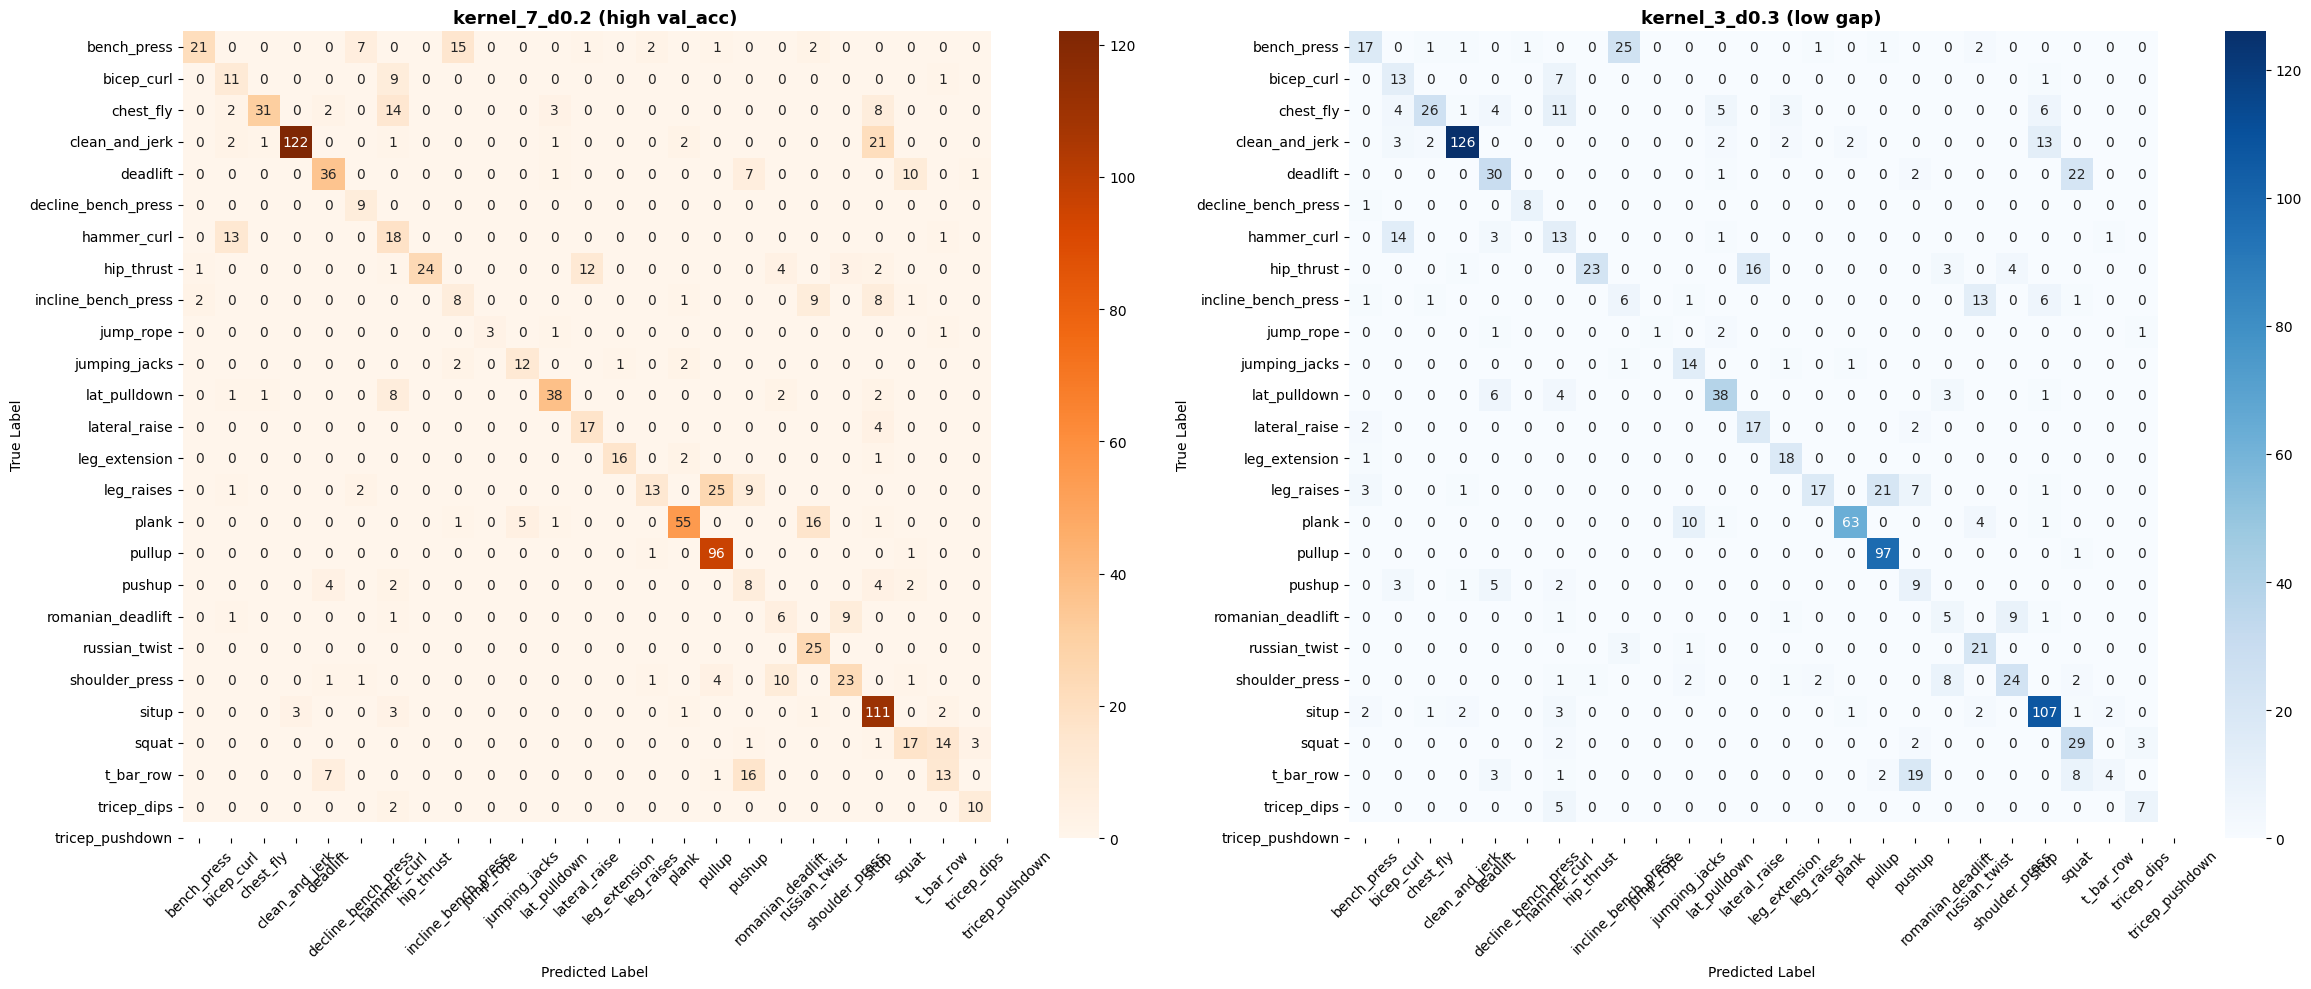

In [20]:
from tensorflow.keras.models import load_model

model_high_acc = load_model(f'{BASE}/models/cnn_kernel_7_d0.2_final.keras')
model_stable = load_model(f'{BASE}/models/cnn_kernel_3_d0.3.keras')

y_pred_high_acc = np.argmax(model_high_acc.predict(X_val, verbose=0), axis=1)
y_pred_stable = np.argmax(model_stable.predict(X_val, verbose=0), axis=1)

cm_high_acc = confusion_matrix(y_val_idx, y_pred_high_acc)
cm_stable = confusion_matrix(y_val_idx, y_pred_stable)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

sns.heatmap(cm_high_acc, annot=True, fmt='d', cmap='Oranges',
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title('kernel_7_d0.2 (high val_acc)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_stable, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title('kernel_3_d0.3 (low gap)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{BASE}/models/cnn_comparison_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
report_high_acc = classification_report(
    y_val_idx, y_pred_high_acc, labels=list(range(len(classes))),
    target_names=classes, output_dict=True
)
report_stable = classification_report(
    y_val_idx, y_pred_stable, labels=list(range(len(classes))),
    target_names=classes, output_dict=True
)

comparison_rows = []
for cls in classes:
    comparison_rows.append({
        'class': cls,
        'f1_kernel7_d0.2': report_high_acc[cls]['f1-score'],
        'f1_kernel3_d0.3': report_stable[cls]['f1-score'],
        'diff': report_stable[cls]['f1-score'] - report_high_acc[cls]['f1-score']
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('diff')
print("=== Per-class F1 შედარება (val set) ===")
print(comparison_df.to_string(index=False))

print(f"\nOverall macro F1 — kernel_7_d0.2: {report_high_acc['macro avg']['f1-score']:.4f}")
print(f"Overall macro F1 — kernel_3_d0.3: {report_stable['macro avg']['f1-score']:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

=== Per-class F1 შედარება (val set) ===
              class  f1_kernel7_d0.2  f1_kernel3_d0.3      diff
          jump_rope         0.750000         0.333333 -0.416667
        tricep_dips         0.376812         0.181818 -0.194993
    tricep_pushdown         0.769231         0.608696 -0.160535
        bench_press         0.575342         0.447368 -0.127974
           deadlift         0.685714         0.560748 -0.124967
incline_bench_press         0.290909         0.187500 -0.103409
          chest_fly         0.666667         0.571429 -0.095238
         leg_raises         0.888889         0.800000 -0.088889
       lat_pulldown         0.705882         0.622222 -0.083660
        hammer_curl         0.395604         0.317073 -0.078531
      lateral_raise         0.783505         0.745098 -0.038407
      leg_extension         0.666667         0.629630 -0.037037
      russian_twist         0.307692         0.277778 -0.029915
         hip_thrust         0.676056         0.647887 -0.028169


In [22]:
import joblib
import numpy as np
from tensorflow.keras.models import load_model

# 1. Feature extractor (identity transform, data already preprocessed in 2A)
class ExtendedFeatureExtractor:
    def __init__(self):
        pass
    def transform(self, X):
        return X

# 2. Unified custom pipeline class (robust, error-protected)
class CNNPipeline:
    def __init__(self, extractor, model_path):
        self.extractor = extractor
        self.model_path = model_path
        self._model = None

    def predict(self, X):
        # Lazy loading: model loads only when predict is called
        if self._model is None:
            print(f"-> Loading Keras model from: {self.model_path}")
            self._model = load_model(self.model_path)

        # Feature transformation
        X_trans = self.extractor.transform(X)
        # Model prediction
        preds_probs = self._model.predict(X_trans, verbose=0)
        return np.argmax(preds_probs, axis=1)

# 3. Path to the champion CNN model (kernel_7, dropout=0.2, best per-class performance)
saved_model_path = f'{BASE}/models/cnn_kernel_7_d0.2_final.keras'

# 4. Create pipeline instance
p2_cnn_pipeline = CNNPipeline(
    extractor=ExtendedFeatureExtractor(),
    model_path=saved_model_path
)

# 5. Save to file
joblib.dump(p2_cnn_pipeline, "p2_cnn_pipeline.pkl")
print("Pipeline saved successfully as: p2_cnn_pipeline.pkl")

Pipeline saved successfully as: p2_cnn_pipeline.pkl


In [23]:
import wandb

# 1. Open a new run specifically for artifact upload
run = wandb.init(
    project="ildolcefarniente",
    group="p2_cnn",
    name="upload_best_p2_cnn_pipeline",
)

# 2. Create artifact for the model
artifact = wandb.Artifact(name="best_p2_cnn_pipeline", type="model")
artifact.add_file("p2_cnn_pipeline.pkl")

# 3. Log the artifact with tags (for Registry)
run.log_artifact(artifact, aliases=["latest", "best_p2_cnn"])

# 4. Close the run
wandb.finish()
print("Pipeline uploaded to WandB!")


Pipeline uploaded to WandB!
